# Notebook 3: Traditional ML Sentiment Classification
**Project:** Sentiment Analysis on Trustpilot Marketing Reviews  
**Client:** Candy Factory Group - Pannipitiya  
**Input:** `data/processed/reviews_cleaned.csv`  
**Models:** Logistic Regression · Naive Bayes · Linear SVM  
**Vectorizer:** TF-IDF  
**Output:** `reports/ml_model_results.csv` · saved model files

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

# Sklearn - feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Sklearn - models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

# Sklearn - pipeline & utilities
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder

# Sklearn - evaluation
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, f1_score
)

os.makedirs('../reports/figures', exist_ok=True)
os.makedirs('../models', exist_ok=True)

sns.set_theme(style='whitegrid')
print("Libraries loaded")

Libraries loaded


## 2. Load Cleaned Dataset

In [14]:
df = pd.read_csv('../data/processed/reviews_cleaned.csv')

print(f"Shape   : {df.shape}")
print(f"Columns : {df.columns.tolist()}")
print()
print("Sentiment distribution:")
print(df['sentiment'].value_counts())
print()
print("Label distribution:")
print(df['label'].value_counts().sort_index())

df[['processed_text', 'sentiment', 'label']].head(5)

Shape   : (3585, 12)
Columns : ['name', 'author_name', 'review_title', 'review_text', 'full_review', 'processed_text', 'rating', 'sentiment', 'label', 'review_length', 'token_count_after', 'reviewed_at']

Sentiment distribution:
sentiment
Positive    2873
Negative     648
Neutral       64
Name: count, dtype: int64

Label distribution:
label
0     648
1      64
2    2873
Name: count, dtype: int64


,processed_text,sentiment,label
0,low price country low price country want crack...,Positive,2
1,time take notice time take notice let know go ...,Positive,2
2,deliver time deliver time product describe pac...,Positive,2
3,quick efficient service quick efficient servic...,Positive,2
4,excellent service pack well excellent service ...,Positive,2


## 3. Prepare Features and Target
`processed_text` -> X (input)  
`label` -> y (target: 0 = Negative, 1 = Neutral, 2 = Positive)

In [15]:
# Drop any remaining nulls in processed_text
df = df.dropna(subset=['processed_text']).reset_index(drop=True)
df['processed_text'] = df['processed_text'].astype(str)

X = df['processed_text']
y = df['label']

label_names = ['Negative', 'Neutral', 'Positive']

print(f"Total samples : {len(X)}")
print(f"Class counts  :")
for i, name in enumerate(label_names):
    print(f"  {i} ({name}) : {(y == i).sum()}")

Total samples : 3585
Class counts  :
  0 (Negative) : 648
  1 (Neutral) : 64
  2 (Positive) : 2873


## 4. Train / Test Split
Stratified split preserves class proportions in both train and test sets.  
80% train · 20% test - consistent seed for reproducibility.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # preserve class balance in both splits
)

print(f"Train size : {len(X_train)}")
print(f"Test size  : {len(X_test)}")
print()
print("Train label distribution:")
print(pd.Series(y_train).value_counts().sort_index())
print()
print("Test label distribution:")
print(pd.Series(y_test).value_counts().sort_index())

Train size : 2868
Test size  : 717

Train label distribution:
label
0     518
1      51
2    2299
Name: count, dtype: int64

Test label distribution:
label
0    130
1     13
2    574
Name: count, dtype: int64


## 5. TF-IDF Vectorizer
TF-IDF (Term Frequency–Inverse Document Frequency) converts text into numeric features.  
Words common across all reviews (low IDF) get lower weight.  
Words specific to certain reviews (high TF, high IDF) get higher weight.

In [17]:
tfidf = TfidfVectorizer(
    max_features=10000,     # keep top 10k most informative words
    ngram_range=(1, 2),     # unigrams + bigrams (e.g. "not good", "highly recommend")
    sublinear_tf=True,      # log-scale TF to reduce impact of very frequent words
    min_df=2                # ignore terms appearing in fewer than 2 documents
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"TF-IDF matrix shape (train) : {X_train_tfidf.shape}")
print(f"TF-IDF matrix shape (test)  : {X_test_tfidf.shape}")
print(f"\nSample top features: {tfidf.get_feature_names_out()[:20]}")

TF-IDF matrix shape (train) : (2868, 8714)
TF-IDF matrix shape (test)  : (717, 8714)

Sample top features: ['ability' 'abit' 'able' 'able build' 'able discuss' 'able help'
 'able offer' 'able return' 'able speak' 'able talk' 'able track' 'abroad'
 'abrupt' 'absence' 'absolute' 'absolute disgrace' 'absolute joke'
 'absolute perfect' 'absolute scam' 'absolutely']


## 6. Define and Train Models
Three models trained on the same TF-IDF features.  
`class_weight='balanced'` handles the class imbalance (75% Positive).

In [18]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',    # handles 75% Positive imbalance
        random_state=42
    ),
    'Naive Bayes': MultinomialNB(
        alpha=0.1                   # smoothing parameter
        # Note: MultinomialNB does not support class_weight
        # It handles imbalance implicitly via prior probabilities
    ),
    'Linear SVM': LinearSVC(
        max_iter=2000,
        class_weight='balanced',    # handles 75% Positive imbalance
        random_state=42
    )
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    trained_models[name] = model
    print(f"Trained: {name}")

Trained: Logistic Regression
Trained: Naive Bayes
Trained: Linear SVM


## 7. Evaluate All Models
Accuracy · Precision · Recall · F1-Score (macro) per model.  
Macro F1 is the key metric here - it treats all classes equally, important given class imbalance.

In [19]:
results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test_tfidf)

    acc     = accuracy_score(y_test, y_pred)
    f1_mac  = f1_score(y_test, y_pred, average='macro')
    f1_wei  = f1_score(y_test, y_pred, average='weighted')

    results.append({
        'Model'         : name,
        'Accuracy'      : round(acc, 4),
        'F1 Macro'      : round(f1_mac, 4),
        'F1 Weighted'   : round(f1_wei, 4)
    })

    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"{'='*50}")
    print(f"Accuracy   : {acc:.4f}")
    print(f"F1 (macro) : {f1_mac:.4f}")
    print(classification_report(y_test, y_pred, target_names=label_names))

results_df = pd.DataFrame(results)
results_df


Model: Logistic Regression
Accuracy   : 0.9261
F1 (macro) : 0.6021
              precision    recall  f1-score   support

    Negative       0.78      0.93      0.85       130
     Neutral       0.00      0.00      0.00        13
    Positive       0.97      0.95      0.96       574

    accuracy                           0.93       717
   macro avg       0.58      0.63      0.60       717
weighted avg       0.92      0.93      0.92       717


Model: Naive Bayes
Accuracy   : 0.9414
F1 (macro) : 0.6153
              precision    recall  f1-score   support

    Negative       0.86      0.90      0.88       130
     Neutral       0.00      0.00      0.00        13
    Positive       0.96      0.97      0.97       574

    accuracy                           0.94       717
   macro avg       0.61      0.62      0.62       717
weighted avg       0.92      0.94      0.93       717


Model: Linear SVM
Accuracy   : 0.9261
F1 (macro) : 0.5994
              precision    recall  f1-score   suppo

,Model,Accuracy,F1 Macro,F1 Weighted
0,Logistic Regression,0.9261,0.6021,0.9221
1,Naive Bayes,0.9414,0.6153,0.9330
2,Linear SVM,0.9261,0.5994,0.9200


## 8. Cross-Validation (5-Fold Stratified)
Single train/test split can be lucky or unlucky.  
Cross-validation gives a more reliable estimate of real-world performance.

In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for name, model in trained_models.items():
    scores = cross_val_score(
        model, X_train_tfidf, y_train,
        cv=cv,
        scoring='f1_macro',
        n_jobs=1            # use 1 to avoid multiprocessing issues on Windows
    )
    cv_results[name] = scores
    print(f"{name:25s} | CV F1 Macro: {scores.mean():.4f} ± {scores.std():.4f}")

Logistic Regression       | CV F1 Macro: 0.6035 ± 0.0046
Naive Bayes               | CV F1 Macro: 0.6057 ± 0.0080
Linear SVM                | CV F1 Macro: 0.5993 ± 0.0066


## 9. Confusion Matrices
Shows where each model makes mistakes — which classes get confused with which.

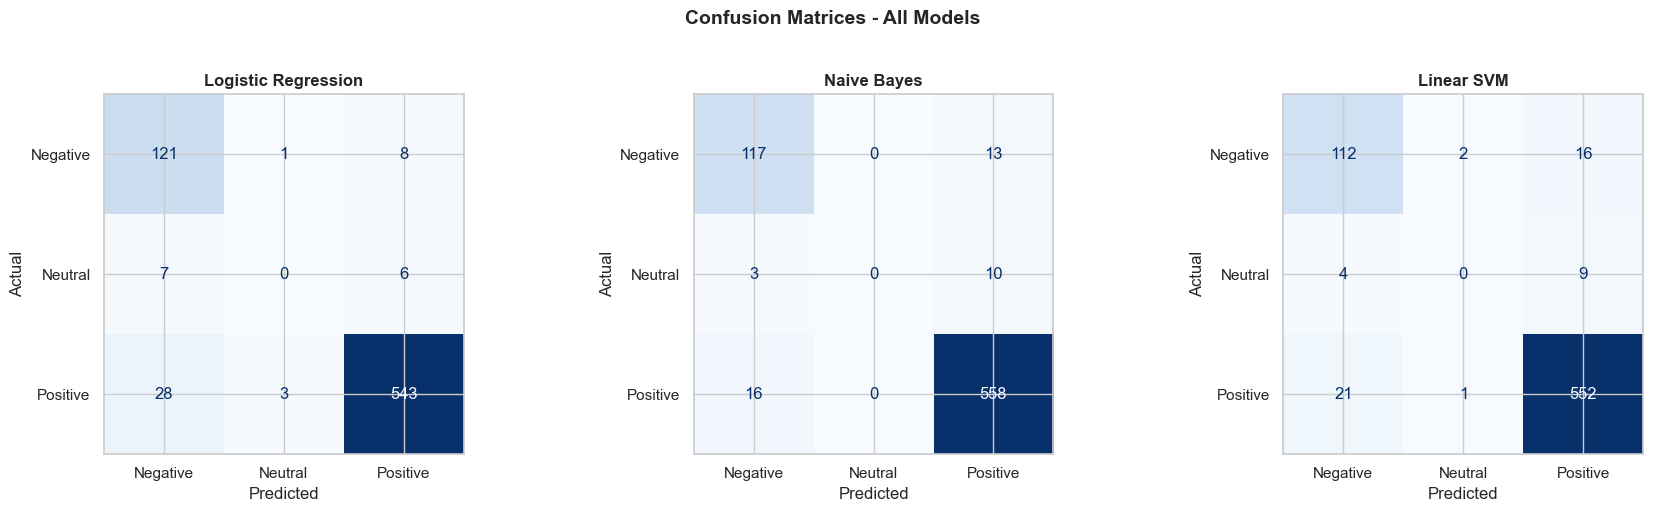

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_test_tfidf)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices - All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrices_ml.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Model Comparison Visualizations

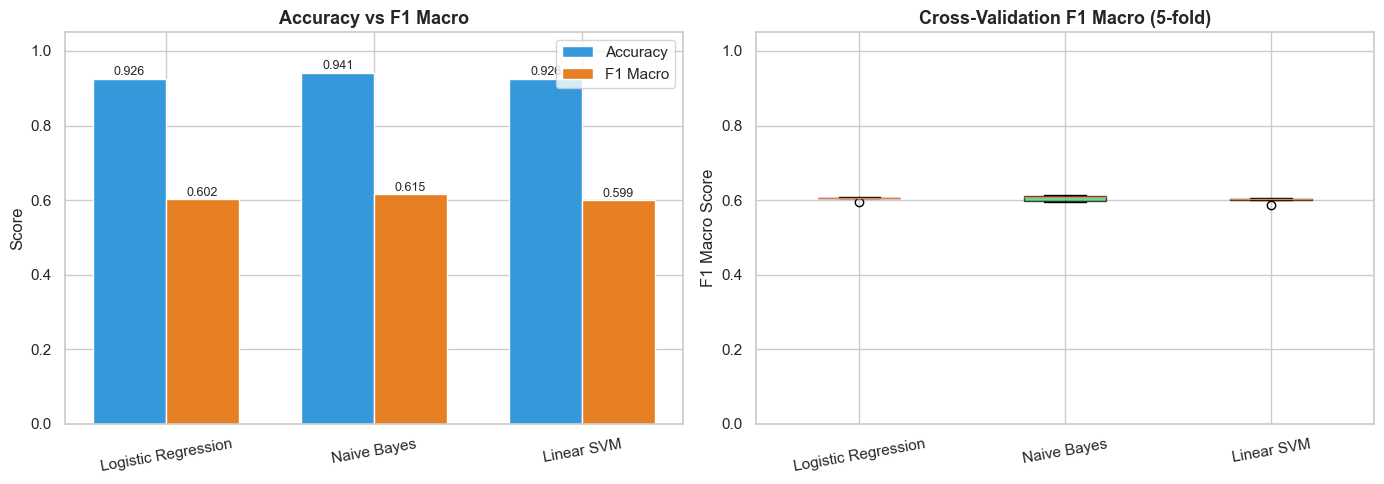

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Bar chart: Accuracy vs F1 Macro ---
x = np.arange(len(results_df))
width = 0.35
axes[0].bar(x - width/2, results_df['Accuracy'], width, label='Accuracy', color='#3498db', edgecolor='white')
axes[0].bar(x + width/2, results_df['F1 Macro'],  width, label='F1 Macro', color='#e67e22', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_df['Model'], rotation=10)
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Accuracy vs F1 Macro', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].legend()
for i, (acc, f1) in enumerate(zip(results_df['Accuracy'], results_df['F1 Macro'])):
    axes[0].text(i - width/2, acc + 0.01, f"{acc:.3f}", ha='center', fontsize=9)
    axes[0].text(i + width/2, f1  + 0.01, f"{f1:.3f}",  ha='center', fontsize=9)

# --- Box plot: Cross-validation F1 spread ---
cv_data = [cv_results[m] for m in results_df['Model']]
bp = axes[1].boxplot(cv_data, patch_artist=True, widths=0.4)
colors_bp = ['#3498db', '#2ecc71', '#e74c3c']
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Fix: set_xticks must come before set_xticklabels (matplotlib >= 3.7)
axes[1].set_xticks(range(1, len(results_df) + 1))
axes[1].set_xticklabels(results_df['Model'], rotation=10)
axes[1].set_title('Cross-Validation F1 Macro (5-fold)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('F1 Macro Score')
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('../reports/figures/ml_model_comparison.png', dpi=150)
plt.show()

## 11. Top TF-IDF Features per Class (Logistic Regression)
Logistic Regression coefficients show which words most strongly predict each sentiment.  
This directly answers: "what words drive positive/negative reviews?"

Classes in coef_: 3 (expected 3)


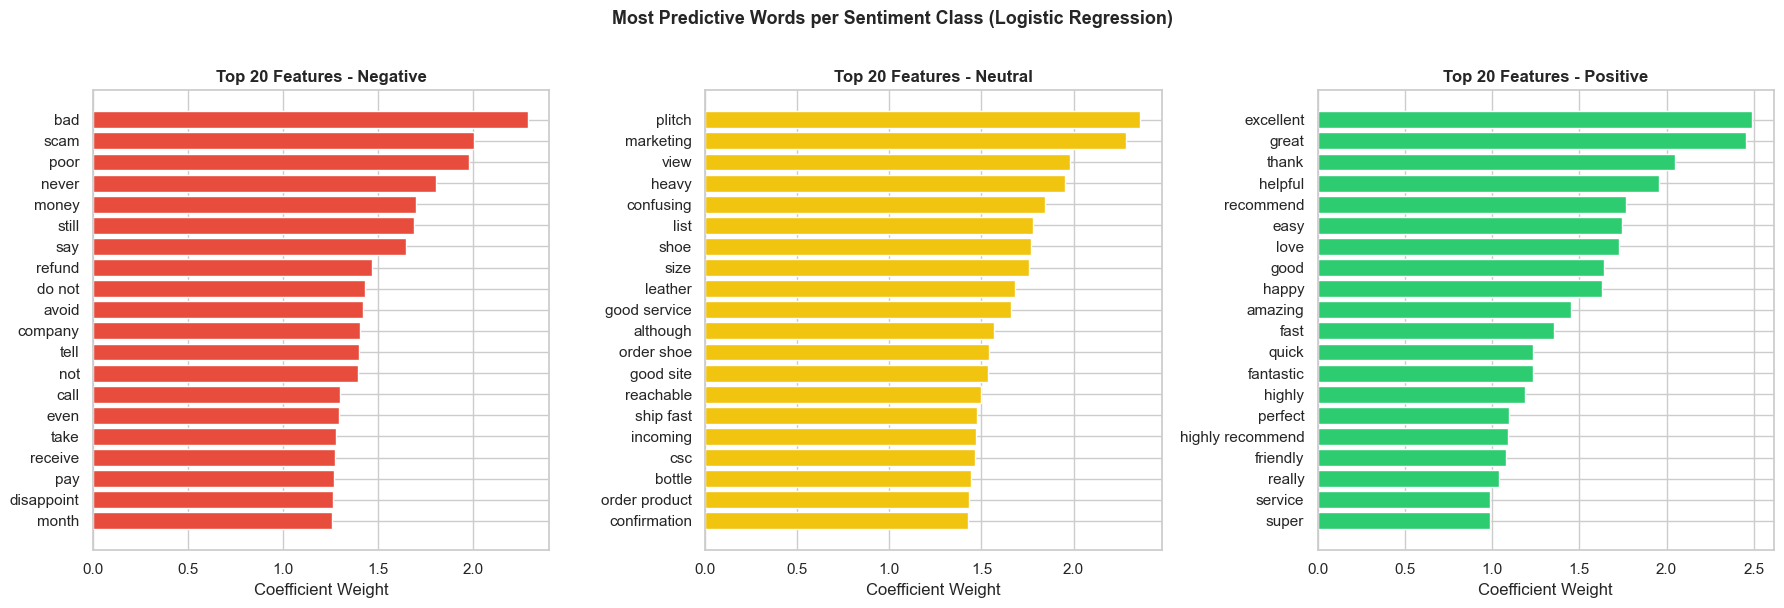

In [23]:
lr_model      = trained_models['Logistic Regression']
feature_names = np.array(tfidf.get_feature_names_out())

# coef_ shape: (n_classes, n_features) for multiclass
# Guard: confirm we have coefficients for all 3 classes
n_classes_found = lr_model.coef_.shape[0]
print(f"Classes in coef_: {n_classes_found} (expected 3)")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors_feat = ['#e74c3c', '#f1c40f', '#2ecc71']

for i, (ax, label, color) in enumerate(zip(axes, label_names, colors_feat)):
    if i >= n_classes_found:
        ax.set_visible(False)
        continue

    coefs    = lr_model.coef_[i]
    top_idx  = np.argsort(coefs)[-20:]
    top_features = feature_names[top_idx]
    top_coefs    = coefs[top_idx]

    ax.barh(top_features, top_coefs, color=color, edgecolor='white')
    ax.set_title(f'Top 20 Features - {label}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Coefficient Weight')

plt.suptitle('Most Predictive Words per Sentiment Class (Logistic Regression)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/top_features_lr.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Save Best Model and Results
Save the best-performing model for comparison with the transformer in notebook 4.

In [24]:
# Identify best model by F1 Macro
best_model_name = results_df.loc[results_df['F1 Macro'].idxmax(), 'Model']
best_model      = trained_models[best_model_name]

# Add CV columns to results_df BEFORE displaying or saving
results_df['CV F1 Mean'] = [round(cv_results[m].mean(), 4) for m in results_df['Model']]
results_df['CV F1 Std']  = [round(cv_results[m].std(),  4) for m in results_df['Model']]

print(f"Best model by F1 Macro: {best_model_name}")
print()
print(results_df.to_string(index=False))

# Save best model + TF-IDF vectorizer
joblib.dump(best_model, '../models/best_ml_model.pkl')
joblib.dump(tfidf,      '../models/tfidf_vectorizer.pkl')
print(f"\nSaved best_ml_model.pkl  ({best_model_name})")
print("Saved tfidf_vectorizer.pkl")

# Save full results to CSV for final comparison report
results_df.to_csv('../reports/ml_model_results.csv', index=False)
print("Saved ml_model_results.csv")

Best model by F1 Macro: Naive Bayes

              Model  Accuracy  F1 Macro  F1 Weighted  CV F1 Mean  CV F1 Std
Logistic Regression    0.9261    0.6021       0.9221      0.6035     0.0046
        Naive Bayes    0.9414    0.6153       0.9330      0.6057     0.0080
         Linear SVM    0.9261    0.5994       0.9200      0.5993     0.0066

Saved best_ml_model.pkl  (Naive Bayes)
Saved tfidf_vectorizer.pkl
Saved ml_model_results.csv


## ML Models Summary

| Model | Strength | Weakness |
|---|---|---|
| Logistic Regression | Interpretable, stable, good baseline | Assumes linear decision boundary |
| Naive Bayes | Fast, works well with sparse TF-IDF | Independence assumption often violated |
| Linear SVM | Strong on high-dimensional text data | Less interpretable, no probability output |

**Key outputs saved:**
- `models/best_ml_model.pkl` - best model for inference
- `models/tfidf_vectorizer.pkl` - vectorizer to transform new text
- `reports/ml_model_results.csv` - metrics for final comparison
- `reports/figures/` - confusion matrices, comparison charts, feature importance

**Next -> `04_transformer_model.ipynb` - DistilBERT fine-tuning and final model comparison**